# Strong heuristic test with physical topology, traffic, mobility, and A3 time

This notebook does **not** use `GLOBAL_SNAPSHOT_SCENARIOS` and does not inject a target load matrix. Each load is produced by real UE placement, serving-cell attachment, offered traffic, radio conditions, and scheduler service.

The experiment also respects handover feasibility:

- UE mobility changes RSRP over physical time.
- The heuristic is updated every control interval from live environment measurements.
- A3 execution still requires the configured hysteresis and time-to-trigger.
- Predicted handovers are compared with handovers actually executed by the environment.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-chech")

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
RESULT_DIR = ROOT / "results" / "strong_heuristic_env_load_scenarios"
RESULT_DIR.mkdir(parents=True, exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scenario_creator import create_multignb_env
from strong_heuristic_local_executor import OFFSET_SET_DB, strong_heuristic_local_executor

SLICE_TYPES = ("eMBB", "URLLC", "mMTC")
SLICE_INDEX = {name: idx for idx, name in enumerate(SLICE_TYPES)}
NEIGHBORS = {0: [1, 2], 1: [0, 2], 2: [0, 1]}

# Coherent time model.
TICK_S = 0.1
SIMULATION_S = 30.0
CONTROL_INTERVAL_S = 5.0
HANDOVER_COOLDOWN_S = 5.0
MIN_RESIDENCE_S = 15.0
EMERGENCY_SINR_DB = -5.0
A3_TTT_S = 0.5
A3_HYSTERESIS_DB = 1.0
N_TICKS = int(round(SIMULATION_S / TICK_S))
CONTROL_TICKS = int(round(CONTROL_INTERVAL_S / TICK_S))
A3_TTT_TICKS = int(round(A3_TTT_S / TICK_S))

GNB_CONFIGS = (
    {"id": 0, "x": 0.0, "y": 0.0, "coverage_radius": 520.0, "carrier_id": 0, "n_prbs": 100},
    {"id": 1, "x": 450.0, "y": 0.0, "coverage_radius": 520.0, "carrier_id": 0, "n_prbs": 100},
    {"id": 2, "x": 225.0, "y": 390.0, "coverage_radius": 520.0, "carrier_id": 0, "n_prbs": 100},
)

print({
    "radio_and_mobility_tick_s": TICK_S,
    "simulation_s": SIMULATION_S,
    "heuristic_control_interval_s": CONTROL_INTERVAL_S,
    "handover_cooldown_s": HANDOVER_COOLDOWN_S,
    "minimum_residence_s": MIN_RESIDENCE_S,
    "emergency_sinr_db": EMERGENCY_SINR_DB,
    "a3_ttt_s": A3_TTT_S,
    "a3_ttt_ticks": A3_TTT_TICKS,
    "a3_hysteresis_db": A3_HYSTERESIS_DB,
})

{'radio_and_mobility_tick_s': 0.1, 'simulation_s': 30.0, 'heuristic_control_interval_s': 5.0, 'handover_cooldown_s': 5.0, 'minimum_residence_s': 15.0, 'emergency_sinr_db': -5.0, 'a3_ttt_s': 0.5, 'a3_ttt_ticks': 5, 'a3_hysteresis_db': 1.0}


## Physically defined UE scenarios

These are UE specifications, not load matrices. `bit_rate` creates demand; position and velocity create topology and future handover opportunities.

In [2]:
DEMAND_PERIODS = (
    {"start_s": 0.0, "end_s": 10.0, "label": "low demand", "multiplier": 0.35, "color": "#dbeafe"},
    {"start_s": 10.0, "end_s": 20.0, "label": "peak demand", "multiplier": 1.00, "color": "#fee2e2"},
    {"start_s": 20.0, "end_s": 30.0, "label": "recovery demand", "multiplier": 0.50, "color": "#dcfce7"},
)


def demand_schedule(base_bit_rate):
    return [
        {"time_s": period["start_s"], "bit_rate": base_bit_rate * period["multiplier"]}
        for period in DEMAND_PERIODS
    ]


def ue(name, slice_type, x, y, vx, vy, bit_rate_mbps):
    base_bit_rate = float(bit_rate_mbps) * 1e6
    return {
        "name": name,
        "slice_type": slice_type,
        "x": float(x), "y": float(y),
        "vx": float(vx), "vy": float(vy),
        "bit_rate": base_bit_rate,
        "bit_rate_schedule": demand_schedule(base_bit_rate),
    }


SCENARIOS = {
    # Many high-demand eMBB UEs begin inside gNB0 and move toward gNB1.
    # Load and radio geometry both support eventual offload.
    "g0_embb_moving_to_g1": [
        ue("e0", "eMBB", 120, -45, 5.0, 0.4, 18),
        ue("e1", "eMBB", 135, -20, 5.0, 0.2, 18),
        ue("e2", "eMBB", 145,   5, 5.0, 0.0, 18),
        ue("e3", "eMBB", 155,  30, 5.0, -0.2, 18),
        ue("e4", "eMBB", 165,  55, 5.0, -0.4, 18),
        ue("u1", "URLLC", 450, 70, 0.0, 0.0, 4),
        ue("m1", "mMTC", 225, 330, 0.0, 0.0, 1),
    ],

    # High URLLC demand is near the center of gNB1 and stationary.
    # The cell may be loaded, but handover should remain radio-infeasible.
    "g1_urllc_center_no_feasible_ho": [
        ue("u0", "URLLC", 420, -35, 0.0, 0.0, 10),
        ue("u1", "URLLC", 440, -15, 0.0, 0.0, 10),
        ue("u2", "URLLC", 460,   5, 0.0, 0.0, 10),
        ue("u3", "URLLC", 480,  25, 0.0, 0.0, 10),
        ue("u4", "URLLC", 450,  50, 0.0, 0.0, 10),
        ue("e0", "eMBB", 60, 30, 0.0, 0.0, 5),
        ue("m0", "mMTC", 225, 340, 0.0, 0.0, 1),
    ],

    # gNB0 has movable eMBB UEs, but gNB1 already has a high-demand eMBB group.
    # This tests the target-overload penalty using load caused by real UEs.
    "g0_source_g1_busy_target": [
        ue("src0", "eMBB", 145, -35, 4.5, 0.2, 16),
        ue("src1", "eMBB", 155,   0, 4.5, 0.0, 16),
        ue("src2", "eMBB", 165,  35, 4.5, -0.2, 16),
        ue("dst0", "eMBB", 405, -55, 0.0, 0.0, 20),
        ue("dst1", "eMBB", 430, -20, 0.0, 0.0, 20),
        ue("dst2", "eMBB", 460,  15, 0.0, 0.0, 20),
        ue("dst3", "eMBB", 485,  50, 0.0, 0.0, 20),
        ue("m0", "mMTC", 225, 340, 0.0, 0.0, 1),
    ],

    # Mixed demand distributed around all sites, with different movement vectors.
    "mixed_mobile_balanced": [
        ue("e0", "eMBB",  80,  20,  2.0,  1.0, 10),
        ue("u0", "URLLC", 30, -60,  1.0,  1.5,  5),
        ue("m0", "mMTC",  70, 100,  0.5,  1.0,  1),
        ue("e1", "eMBB", 390, -30, -1.5,  1.0, 10),
        ue("u1", "URLLC", 490,  45, -1.0,  1.0,  5),
        ue("m1", "mMTC", 410, 100, -0.5,  1.0,  1),
        ue("e2", "eMBB", 225, 300,  0.0, -1.5, 10),
        ue("u2", "URLLC", 180, 370,  1.0, -1.0,  5),
        ue("m2", "mMTC", 270, 380, -1.0, -1.0,  1),
    ],
}

pd.DataFrame([
    {"scenario": scenario, "n_ues": len(specs), "offered_Mbps": sum(s["bit_rate"] for s in specs) / 1e6}
    for scenario, specs in SCENARIOS.items()
])

,scenario,n_ues,offered_Mbps
0,g0_embb_moving_to_g1,7,95.0
1,g1_urllc_center_no_feasible_ho,7,56.0
2,g0_source_g1_busy_target,8,129.0
3,mixed_mobile_balanced,9,48.0


## Environment and live measurement helpers

In [3]:
def make_env(specs, seed):
    env = create_multignb_env(
        rng=np.random.default_rng(seed),
        n=4,
        slots_per_step=1,
        L1_level=False,
        gnb_configs=GNB_CONFIGS,
        step_dt=TICK_S,
        mobility_dt=TICK_S,
        radio_substeps=1,
        max_episode_steps=N_TICKS + 1,
        handover_ttt=A3_TTT_TICKS,
        a3_handover_cooldown_s=HANDOVER_COOLDOWN_S,
        a3_min_residence_s=MIN_RESIDENCE_S,
        a3_emergency_sinr_db=EMERGENCY_SINR_DB,
        max_prbs_per_ue=None,
    )
    env.a3_hysteresis_db = A3_HYSTERESIS_DB
    names = {}
    for spec in specs:
        ue_id = env.add_ue(
            x=spec["x"], y=spec["y"], vx=spec["vx"], vy=spec["vy"],
            slice_type=spec["slice_type"], bit_rate=spec["bit_rate"],
            bit_rate_schedule=spec["bit_rate_schedule"],
            packet_size_bits=12000.0, traffic_model="fixed_packet_cbr",
        )
        names[ue_id] = spec["name"]
    return env, names


def matrix_from_dict(values):
    return np.asarray([
        [float(values.get((g, slice_type), 0.0)) for slice_type in SLICE_TYPES]
        for g in range(3)
    ], dtype=float)


def aggregate_ratio(values):
    matrix = np.zeros((3, 3), dtype=float)
    counts = np.zeros((3, 3), dtype=float)
    for (serving, _target, slice_type), value in values.items():
        normalized = str(slice_type).upper()
        names = {"EMBB": 0, "URLLC": 1, "MMTC": 2}
        if normalized in names:
            matrix[int(serving), names[normalized]] += max(float(value), 0.0)
            counts[int(serving), names[normalized]] += 1.0
    return matrix / np.maximum(counts, 1.0)


def live_executor_inputs(env):
    connected = [ue for ue in env.get_all_ues() if ue.connected and ue.serving_gnb is not None]
    ue_slice = np.asarray([SLICE_INDEX[env.normalize_slice_type(ue.slice_type)] for ue in connected], dtype=int)
    serving = np.asarray([int(ue.serving_gnb) for ue in connected], dtype=int)
    rsrp = np.asarray([
        [float(env._measure_rsrp(env._get_gnb_by_id(g), ue)) for g in range(3)]
        for ue in connected
    ], dtype=float)
    return {
        "ue_slice": ue_slice,
        "ue_serving_gnb": serving,
        "rsrp_matrix": rsrp,
        "neighbor_graph": NEIGHBORS,
        "load": matrix_from_dict(env.get_slice_loads()),
        "sla_violation": np.clip(matrix_from_dict(env.get_slice_sla_flags()), 0.0, 1.0),
        "ho_failure_ratio": aggregate_ratio(env.get_handover_failure_ratios()),
        "pingpong_ratio": aggregate_ratio(env.get_ping_pong_ratios()),
    }


def load_aware_bias(load, deadband=0.05, gain=4.0):
    per_slice_mean = np.mean(load, axis=0, keepdims=True)
    delta = load - per_slice_mean
    bias = np.clip(-gain * delta, -1.0, 1.0)
    bias[np.abs(delta) <= deadband] = 0.0
    return bias


def apply_offsets(env, offsets):
    for serving, targets in NEIGHBORS.items():
        for target in targets:
            for slice_idx, slice_type in enumerate(SLICE_TYPES):
                env.set_a3_offset(serving, target, slice_type, offsets[serving, slice_idx])

## Topology before simulation

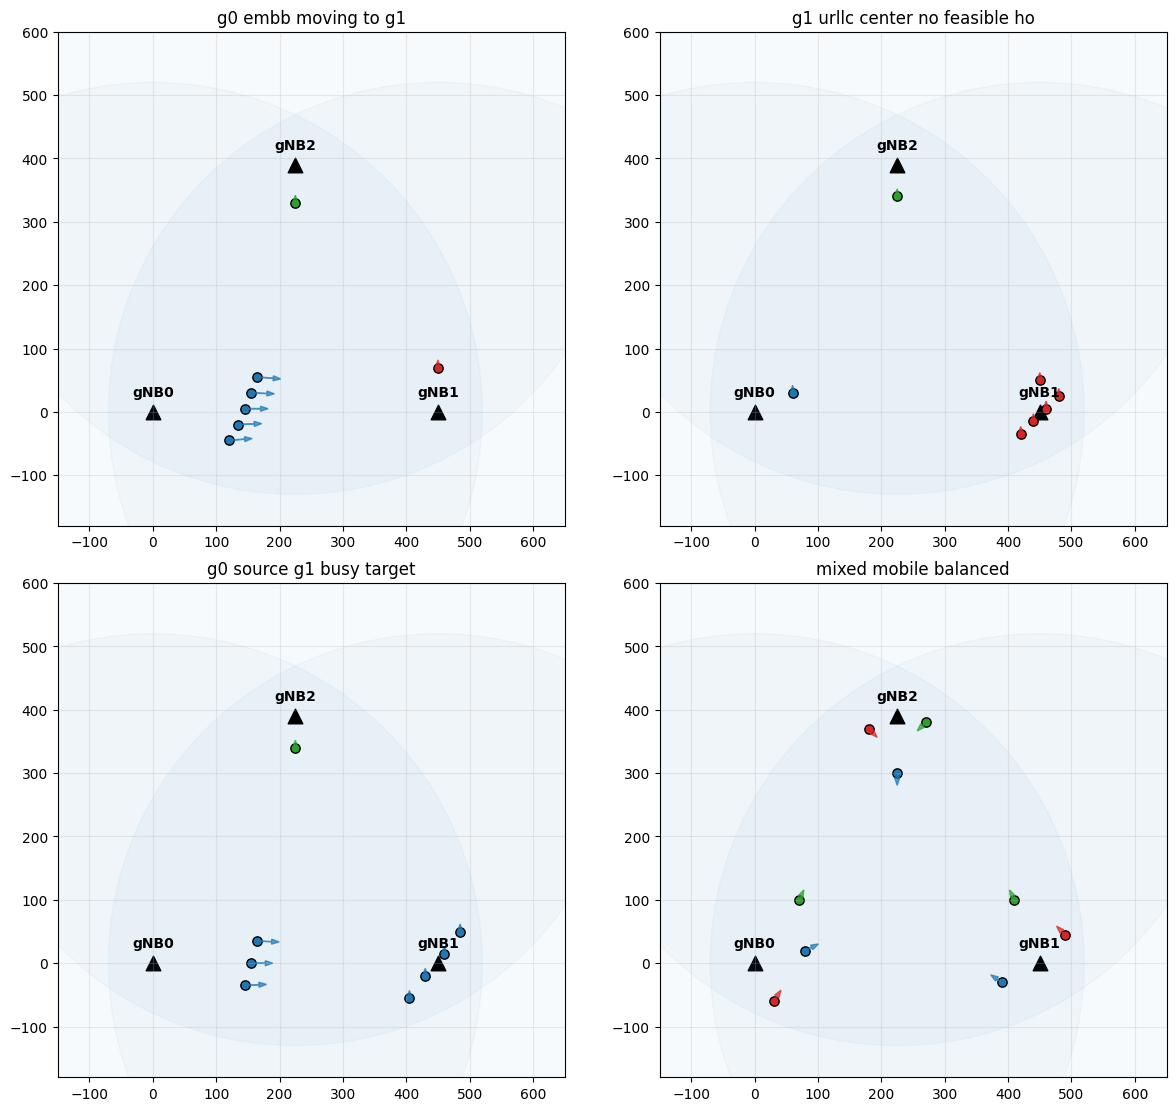

In [4]:
def plot_topology(ax, specs, title):
    for cfg in GNB_CONFIGS:
        circle = plt.Circle((cfg["x"], cfg["y"]), cfg["coverage_radius"], color="tab:blue", alpha=0.035)
        ax.add_patch(circle)
        ax.scatter(cfg["x"], cfg["y"], marker="^", s=110, color="black")
        ax.text(cfg["x"], cfg["y"] + 25, f"gNB{cfg['id']}", ha="center", weight="bold")
    colors = {"eMBB": "tab:blue", "URLLC": "tab:red", "mMTC": "tab:green"}
    for spec in specs:
        ax.scatter(spec["x"], spec["y"], color=colors[spec["slice_type"]], edgecolor="black", s=45)
        ax.arrow(spec["x"], spec["y"], spec["vx"] * 5, spec["vy"] * 5,
                 color=colors[spec["slice_type"]], width=0.7, head_width=8, alpha=0.7)
    ax.set_title(title.replace("_", " "))
    ax.set_xlim(-150, 650); ax.set_ylim(-180, 600)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.25)


fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)
for ax, (scenario, specs) in zip(axes.ravel(), SCENARIOS.items()):
    plot_topology(ax, specs, scenario)
plt.show()

## Run physical simulations

Each scenario is run twice with the same seed and UE topology:

- `baseline`: all A3 offsets remain zero;
- `heuristic`: live load creates the upper bias, and the strong executor selects offsets every second.

In [5]:
def run_simulation(scenario, specs, mode, seed=21):
    env, names = make_env(specs, seed)
    prev_offsets = np.zeros((3, 3), dtype=float)
    trace_rows = []
    control_rows = []
    ue_rows = []

    for tick in range(N_TICKS):
        time_s = tick * TICK_S
        if tick % CONTROL_TICKS == 0:
            inputs = live_executor_inputs(env)
            if mode == "heuristic":
                bias = load_aware_bias(inputs["load"])
                offsets, debug = strong_heuristic_local_executor(
                    B=bias,
                    prev_offsets=prev_offsets,
                    **inputs,
                    hysteresis_db=A3_HYSTERESIS_DB,
                    l_safe=0.85,
                    slice_types=SLICE_TYPES,
                    return_debug=True,
                )
            else:
                bias = np.zeros((3, 3), dtype=float)
                offsets = np.zeros((3, 3), dtype=float)
                debug = {}
            apply_offsets(env, offsets)
            prev_offsets = offsets.copy()
            predicted = sum(
                candidate["n_predicted_handovers"]
                for entry in debug.values()
                for candidate in entry["candidates"]
                if candidate["candidate_offset_db"] == entry["selected_offset_db"]
            ) if debug else 0.0
            control_rows.append({
                "scenario": scenario, "mode": mode, "time_s": time_s,
                "predicted_handovers_now": predicted,
                **{f"bias_g{g}_{s}": bias[g, idx] for g in range(3) for idx, s in enumerate(SLICE_TYPES)},
                **{f"offset_g{g}_{s}": offsets[g, idx] for g in range(3) for idx, s in enumerate(SLICE_TYPES)},
            })

        events_before = len(env.handover_events)
        _, _, terminated, truncated, _ = env.step(0)
        load = matrix_from_dict(env.get_slice_loads())
        events_after = len(env.handover_events)
        for tracked_ue in env.get_all_ues():
            radio = env.get_ue_radio_metrics(tracked_ue.id)
            ue_rows.append({
                "scenario": scenario, "mode": mode, "tick": tick,
                "time_s": (tick + 1) * TICK_S, "name": names[tracked_ue.id],
                "slice": env.normalize_slice_type(tracked_ue.slice_type),
                **radio,
            })
        for g in range(3):
            for s_idx, slice_type in enumerate(SLICE_TYPES):
                trace_rows.append({
                    "scenario": scenario, "mode": mode, "tick": tick,
                    "time_s": (tick + 1) * TICK_S, "gnb": g, "slice": slice_type,
                    "load": load[g, s_idx],
                    "actual_handovers_tick": events_after - events_before,
                })
        if terminated or truncated:
            break

    ue_final = pd.DataFrame([
        {
            "scenario": scenario, "mode": mode, "ue_id": ue.id, "name": names[ue.id],
            "slice": env.normalize_slice_type(ue.slice_type), "x": ue.x, "y": ue.y,
            "serving_gnb": ue.serving_gnb, "throughput_bps": ue.th, "queue_bits": ue.queue,
        }
        for ue in env.get_all_ues()
    ])
    events = pd.DataFrame(env.get_handover_events())
    if not events.empty:
        events["time_s"] = events["step"] * TICK_S
        events["scenario"] = scenario
        events["mode"] = mode
    env.close()
    return pd.DataFrame(trace_rows), pd.DataFrame(control_rows), pd.DataFrame(ue_rows), ue_final, events


traces, controls, ue_traces, final_ues, event_frames = [], [], [], [], []
for scenario, specs in SCENARIOS.items():
    for mode in ("baseline", "heuristic"):
        print(f"running {scenario:34s} {mode}")
        trace, control, ue_trace, final_ue, events = run_simulation(scenario, specs, mode)
        traces.append(trace); controls.append(control); ue_traces.append(ue_trace); final_ues.append(final_ue)
        if not events.empty:
            event_frames.append(events)

trace_df = pd.concat(traces, ignore_index=True)
control_df = pd.concat(controls, ignore_index=True)
ue_trace_df = pd.concat(ue_traces, ignore_index=True)
final_ue_df = pd.concat(final_ues, ignore_index=True)
events_df = pd.concat(event_frames, ignore_index=True) if event_frames else pd.DataFrame()

CSV_FILES = {
    "slice_load_trace": RESULT_DIR / "slice_load_trace.csv",
    "heuristic_control_trace": RESULT_DIR / "heuristic_control_trace.csv",
    "ue_radio_service_trace": RESULT_DIR / "ue_radio_service_trace.csv",
    "handover_events": RESULT_DIR / "handover_events.csv",
    "final_ue_state": RESULT_DIR / "final_ue_state.csv",
}
trace_df.to_csv(CSV_FILES["slice_load_trace"], index=False)
control_df.to_csv(CSV_FILES["heuristic_control_trace"], index=False)
ue_trace_df.to_csv(CSV_FILES["ue_radio_service_trace"], index=False)
events_df.to_csv(CSV_FILES["handover_events"], index=False)
final_ue_df.to_csv(CSV_FILES["final_ue_state"], index=False)

print("trace rows:", len(trace_df), "control rows:", len(control_df),
      "UE rows:", len(ue_trace_df), "handover rows:", len(events_df))
display(pd.DataFrame({"dataset": CSV_FILES.keys(), "csv_path": [str(path) for path in CSV_FILES.values()]}))

running g0_embb_moving_to_g1               baseline
running g0_embb_moving_to_g1               heuristic
running g1_urllc_center_no_feasible_ho     baseline
running g1_urllc_center_no_feasible_ho     heuristic
running g0_source_g1_busy_target           baseline
running g0_source_g1_busy_target           heuristic
running mixed_mobile_balanced              baseline
running mixed_mobile_balanced              heuristic
trace rows: 21600 control rows: 48 UE rows: 18600 handover rows: 16


,dataset,csv_path
0,slice_load_trace,/home/oussama/Desktop/chech/results/strong_heu...
1,heuristic_control_trace,/home/oussama/Desktop/chech/results/strong_heu...
2,ue_radio_service_trace,/home/oussama/Desktop/chech/results/strong_heu...
3,handover_events,/home/oussama/Desktop/chech/results/strong_heu...
4,final_ue_state,/home/oussama/Desktop/chech/results/strong_heu...


## Readable load-matrix timeline

Rows are gNBs, columns are slices, and every cell is the live useful-PRB load. Change `MATRIX_SCENARIO` to inspect another physical scenario.

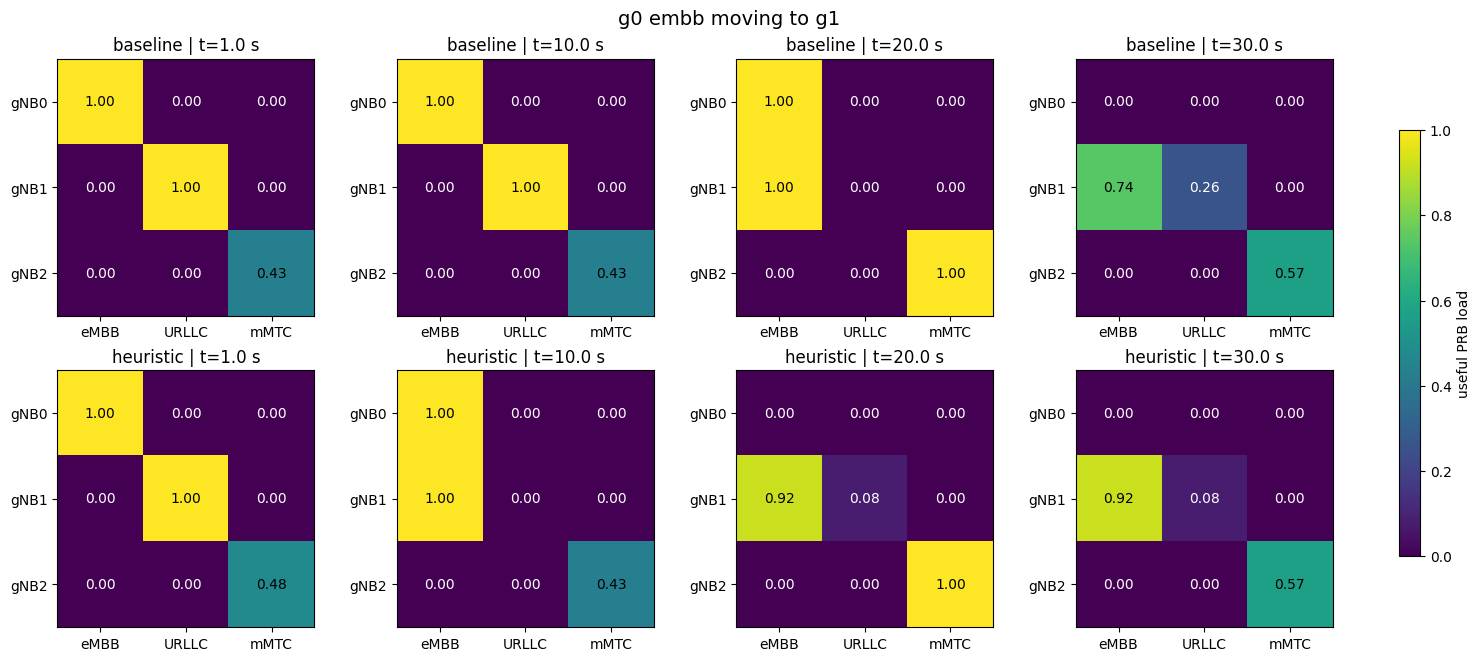

In [6]:
MATRIX_SCENARIO = "g0_embb_moving_to_g1"
MATRIX_TIMES_S = (1.0, 10.0, 20.0, 30.0)


def load_matrix_at(trace, scenario, mode, time_s):
    subset = trace[(trace.scenario == scenario) & (trace["mode"] == mode)]
    available_time = subset.loc[(subset.time_s - time_s).abs().idxmin(), "time_s"]
    rows = subset[subset.time_s == available_time]
    return rows.pivot(index="gnb", columns="slice", values="load").reindex(
        index=range(3), columns=SLICE_TYPES
    ).to_numpy(), float(available_time)


fig, axes = plt.subplots(2, len(MATRIX_TIMES_S), figsize=(15, 6.5), constrained_layout=True)
for row, mode in enumerate(("baseline", "heuristic")):
    for col, requested_time in enumerate(MATRIX_TIMES_S):
        matrix, actual_time = load_matrix_at(trace_df, MATRIX_SCENARIO, mode, requested_time)
        ax = axes[row, col]
        image = ax.imshow(matrix, vmin=0, vmax=1, cmap="viridis")
        ax.set_title(f"{mode} | t={actual_time:.1f} s")
        ax.set_xticks(range(3), SLICE_TYPES)
        ax.set_yticks(range(3), [f"gNB{i}" for i in range(3)])
        for g in range(3):
            for s in range(3):
                value = matrix[g, s]
                ax.text(s, g, f"{value:.2f}", ha="center", va="center",
                        color="white" if value < 0.35 else "black", fontsize=10)
fig.suptitle(MATRIX_SCENARIO.replace("_", " "), fontsize=14)
fig.colorbar(image, ax=axes, shrink=0.75, label="useful PRB load")
plt.show()

## Final load-matrix comparison

This view answers one question per scenario: where did the load finish after 30 seconds with zero offsets versus the heuristic?

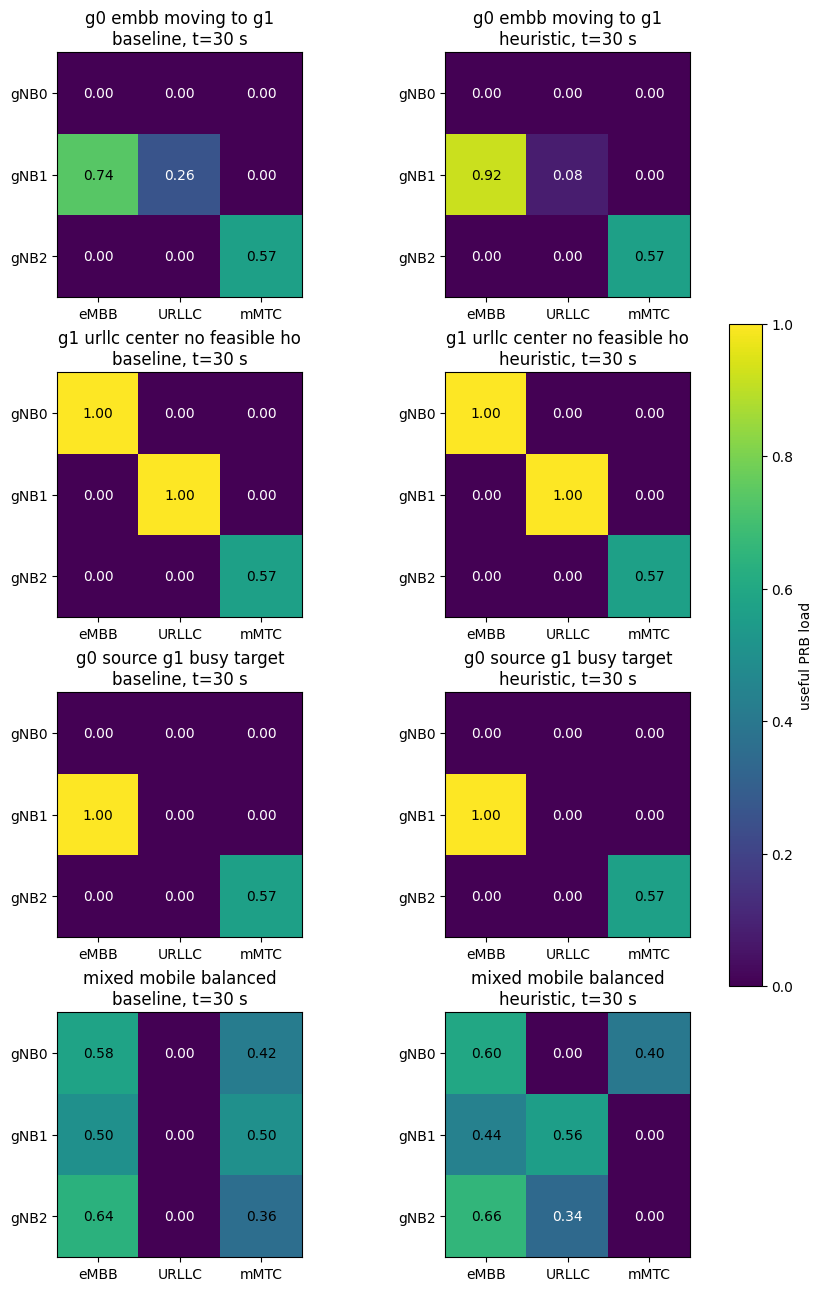

In [7]:
fig, axes = plt.subplots(len(SCENARIOS), 2, figsize=(9, 3.2 * len(SCENARIOS)), constrained_layout=True)
for row, scenario in enumerate(SCENARIOS):
    for col, mode in enumerate(("baseline", "heuristic")):
        matrix, actual_time = load_matrix_at(trace_df, scenario, mode, SIMULATION_S)
        ax = axes[row, col]
        image = ax.imshow(matrix, vmin=0, vmax=1, cmap="viridis")
        ax.set_title(f"{scenario.replace('_', ' ')}\n{mode}, t={actual_time:.0f} s")
        ax.set_xticks(range(3), SLICE_TYPES)
        ax.set_yticks(range(3), [f"gNB{i}" for i in range(3)])
        for g in range(3):
            for s in range(3):
                value = matrix[g, s]
                ax.text(s, g, f"{value:.2f}", ha="center", va="center",
                        color="white" if value < 0.35 else "black")
fig.colorbar(image, ax=axes, shrink=0.55, label="useful PRB load")
plt.show()

## Full heuristic decision matrix

Unlike the load plot, this shows the decision for every gNB-slice pair. An empty slice can have zero load while still receiving a nonzero offset in preparation for future UE arrival.

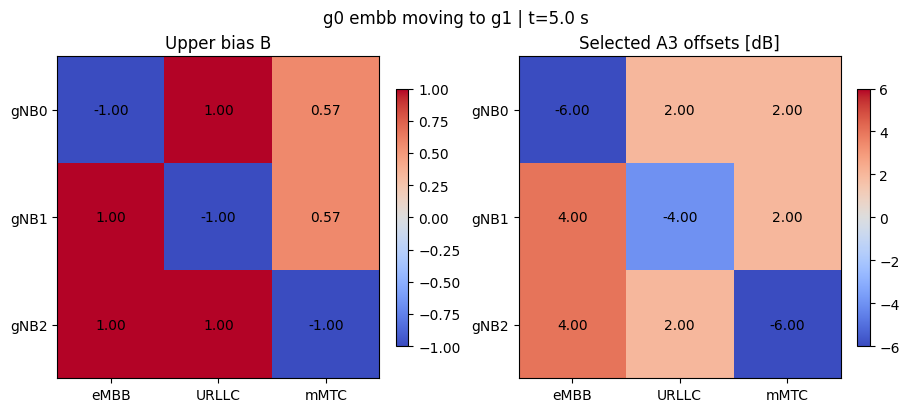

gNB2/eMBB load may be 0, but its configured offset is 4.0 dB


In [8]:
DECISION_SCENARIO = "g0_embb_moving_to_g1"
DECISION_TIME_S = 5.0
decision_rows = control_df[
    (control_df.scenario == DECISION_SCENARIO)
    & (control_df["mode"] == "heuristic")
]
decision_time = decision_rows.loc[(decision_rows.time_s - DECISION_TIME_S).abs().idxmin(), "time_s"]
decision = decision_rows[decision_rows.time_s == decision_time].iloc[0]
bias_matrix = np.asarray([
    [decision[f"bias_g{g}_{slice_type}"] for slice_type in SLICE_TYPES]
    for g in range(3)
], dtype=float)
offset_matrix = np.asarray([
    [decision[f"offset_g{g}_{slice_type}"] for slice_type in SLICE_TYPES]
    for g in range(3)
], dtype=float)

fig, axes = plt.subplots(1, 2, figsize=(9, 4), constrained_layout=True)
for ax, matrix, title, limit in [
    (axes[0], bias_matrix, "Upper bias B", 1),
    (axes[1], offset_matrix, "Selected A3 offsets [dB]", 6),
]:
    image = ax.imshow(matrix, vmin=-limit, vmax=limit, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xticks(range(3), SLICE_TYPES)
    ax.set_yticks(range(3), [f"gNB{i}" for i in range(3)])
    for g in range(3):
        for s in range(3):
            ax.text(s, g, f"{matrix[g, s]:.2f}", ha="center", va="center")
    fig.colorbar(image, ax=ax, shrink=0.75)
fig.suptitle(f"{DECISION_SCENARIO.replace('_', ' ')} | t={decision_time:.1f} s")
plt.show()
print("gNB2/eMBB load may be 0, but its configured offset is", offset_matrix[2, 0], "dB")

## Load over physical time

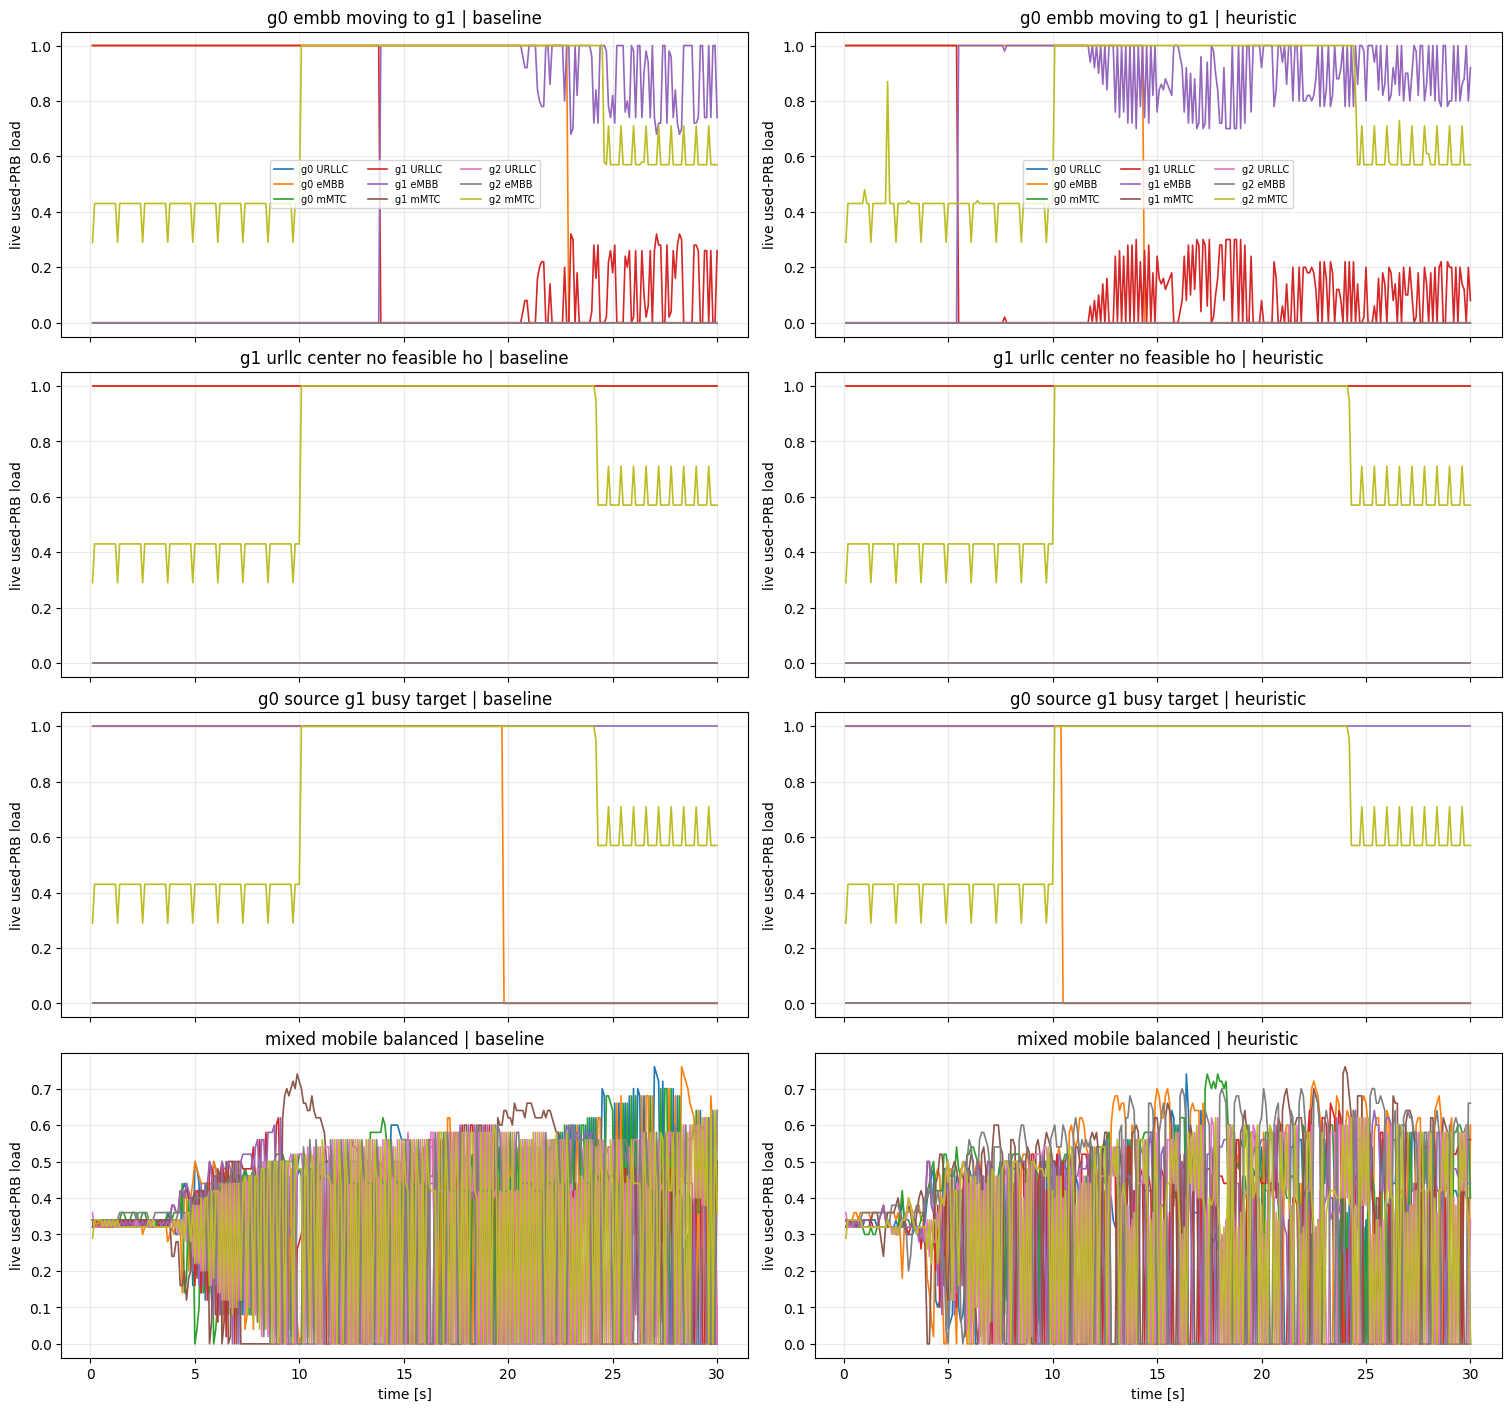

In [9]:
fig, axes = plt.subplots(len(SCENARIOS), 2, figsize=(15, 3.5 * len(SCENARIOS)), sharex=True, constrained_layout=True)
for row, scenario in enumerate(SCENARIOS):
    for col, mode in enumerate(("baseline", "heuristic")):
        ax = axes[row, col]
        subset = trace_df[(trace_df.scenario == scenario) & (trace_df["mode"] == mode)]
        for (gnb, slice_type), group in subset.groupby(["gnb", "slice"]):
            ax.plot(group.time_s, group.load, label=f"g{gnb} {slice_type}", linewidth=1.2)
        ax.set_title(f"{scenario.replace('_', ' ')} | {mode}")
        ax.set_ylabel("live used-PRB load")
        ax.grid(True, alpha=0.25)
        if row == 0:
            ax.legend(ncol=3, fontsize=7)
axes[-1, 0].set_xlabel("time [s]"); axes[-1, 1].set_xlabel("time [s]")
plt.show()

## Bias and offset over time

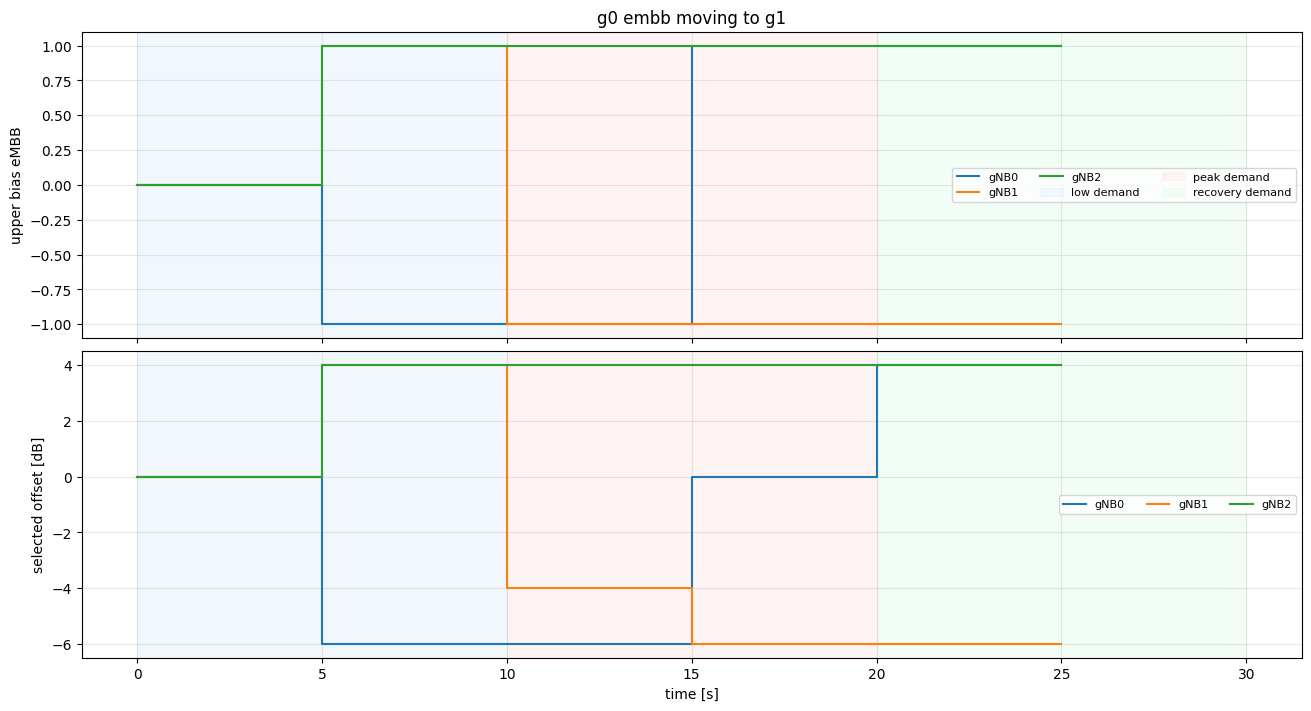

In [10]:
FOCUS_SCENARIO = "g0_embb_moving_to_g1"
focus = control_df[(control_df.scenario == FOCUS_SCENARIO) & (control_df["mode"] == "heuristic")]
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True, constrained_layout=True)
for g in range(3):
    axes[0].step(focus.time_s, focus[f"bias_g{g}_eMBB"], where="post", label=f"gNB{g}")
    axes[1].step(focus.time_s, focus[f"offset_g{g}_eMBB"], where="post", label=f"gNB{g}")
for ax in axes:
    for period in DEMAND_PERIODS:
        ax.axvspan(period["start_s"], period["end_s"], color=period["color"], alpha=0.35,
                   label=period["label"] if ax is axes[0] else None)
axes[0].set_ylabel("upper bias eMBB")
axes[1].set_ylabel("selected offset [dB]"); axes[1].set_xlabel("time [s]")
axes[0].set_title(FOCUS_SCENARIO.replace("_", " "))
for ax in axes:
    ax.grid(True, alpha=0.3); ax.legend(ncol=3, fontsize=8)
plt.show()

## Demand, serving cell, cooldown, and residence timeline

The selected UE timeline highlights why another handover is or is not allowed:

- dark red: hard cooldown, no handover allowed;
- orange: minimum residence protection, only emergency SINR can override;
- blue/red/green background: low, peak, and recovery traffic periods.

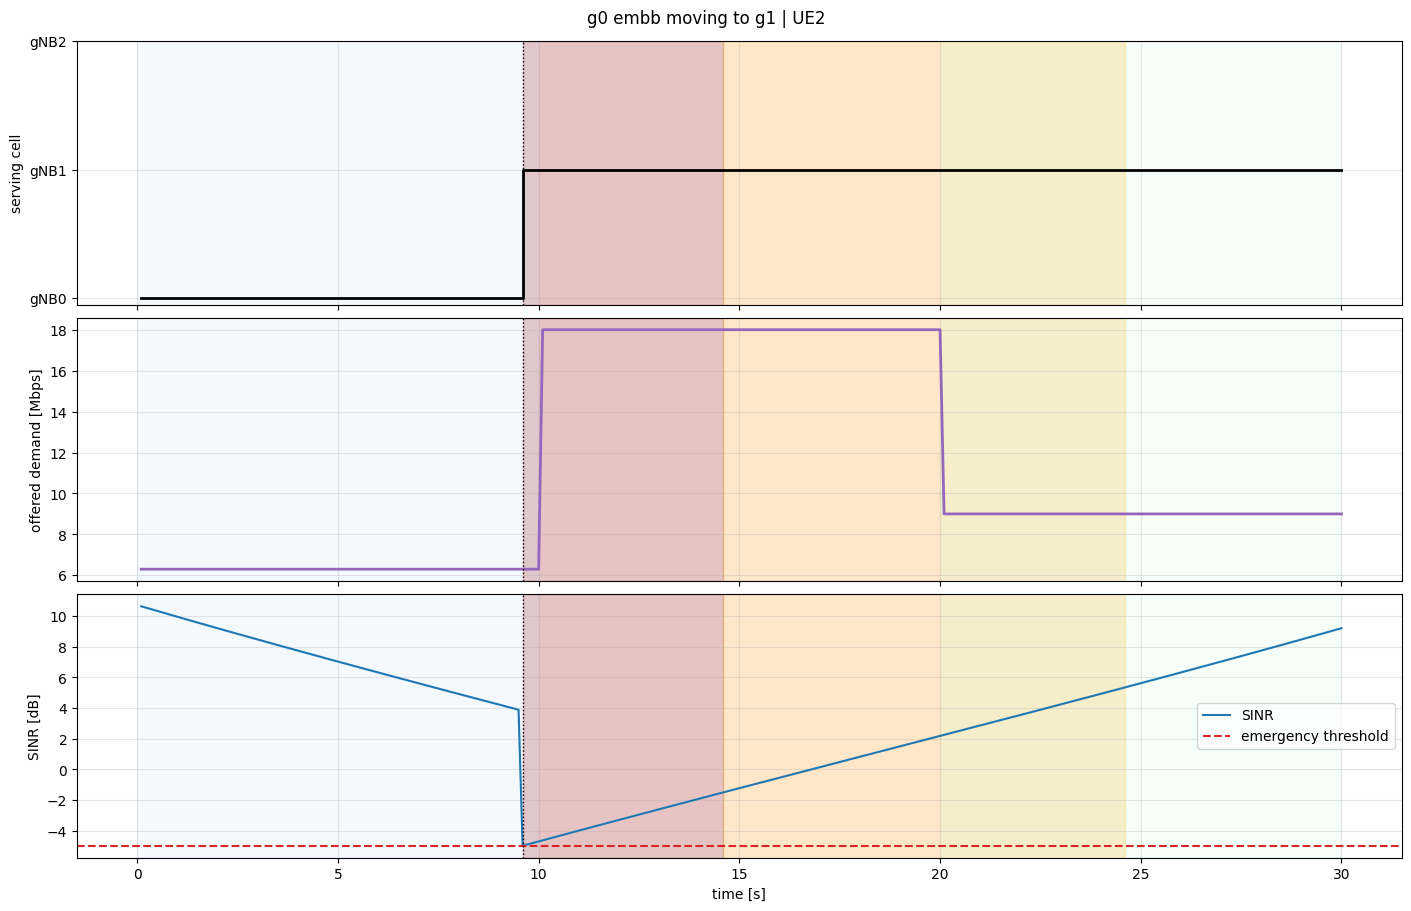

,time_s,from_gnb,to_gnb,offset_db,rsrp_serving_dbm,rsrp_target_dbm
7,9.6,0,1,-6.0,-76.103194,-80.777336


In [11]:
TIMELINE_SCENARIO = "g0_embb_moving_to_g1"
TIMELINE_UE_ID = 2
timeline = ue_trace_df[
    (ue_trace_df.scenario == TIMELINE_SCENARIO)
    & (ue_trace_df["mode"] == "heuristic")
    & (ue_trace_df.ue_id == TIMELINE_UE_ID)
].sort_values("time_s")
ue_events = events_df[
    (events_df.scenario == TIMELINE_SCENARIO)
    & (events_df["mode"] == "heuristic")
    & (events_df.ue_id == TIMELINE_UE_ID)
].sort_values("time_s")

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True, constrained_layout=True)
axes[0].step(timeline.time_s, timeline.serving_gnb, where="post", color="black", linewidth=2)
axes[0].set_yticks(range(3), ["gNB0", "gNB1", "gNB2"])
axes[0].set_ylabel("serving cell")
axes[1].plot(timeline.time_s, timeline.offered_bit_rate / 1e6, color="tab:purple", linewidth=2)
axes[1].set_ylabel("offered demand [Mbps]")
axes[2].plot(timeline.time_s, timeline.sinr_db, label="SINR", color="tab:blue")
axes[2].axhline(EMERGENCY_SINR_DB, color="tab:red", linestyle="--", label="emergency threshold")
axes[2].set_ylabel("SINR [dB]"); axes[2].set_xlabel("time [s]")

for ax in axes:
    for period in DEMAND_PERIODS:
        ax.axvspan(period["start_s"], period["end_s"], color=period["color"], alpha=0.28)
    for event in ue_events.itertuples():
        cooldown_end = min(event.time_s + HANDOVER_COOLDOWN_S, SIMULATION_S)
        residence_end = min(event.time_s + MIN_RESIDENCE_S, SIMULATION_S)
        ax.axvspan(event.time_s, cooldown_end, color="darkred", alpha=0.20)
        ax.axvspan(cooldown_end, residence_end, color="orange", alpha=0.18)
        ax.axvline(event.time_s, color="black", linestyle=":", linewidth=1)
    ax.grid(True, alpha=0.3)
axes[2].legend()
fig.suptitle(f"{TIMELINE_SCENARIO.replace('_', ' ')} | UE{TIMELINE_UE_ID}")
plt.show()
display(ue_events[["time_s", "from_gnb", "to_gnb", "offset_db", "rsrp_serving_dbm", "rsrp_target_dbm"]])

## Predicted versus actually executed handovers

A prediction at one control instant is not an immediate handover. The environment must observe the A3 condition for `A3_TTT_S` before execution.

In [12]:
actual_summary = (
    events_df.groupby(["scenario", "mode"]).size().rename("actual_handovers").reset_index()
    if not events_df.empty else pd.DataFrame(columns=["scenario", "mode", "actual_handovers"])
)
predicted_summary = control_df.groupby(["scenario", "mode"])["predicted_handovers_now"].sum().reset_index()
summary = predicted_summary.merge(actual_summary, on=["scenario", "mode"], how="left").fillna(0)
display(summary)

if not events_df.empty:
    display(events_df[["scenario", "mode", "time_s", "ue_id", "slice_type", "from_gnb", "to_gnb", "offset_db", "rsrp_serving_dbm", "rsrp_target_dbm"]])

,scenario,mode,predicted_handovers_now,actual_handovers
0,g0_embb_moving_to_g1,baseline,0.0,5.0
1,g0_embb_moving_to_g1,heuristic,14.0,5.0
2,g0_source_g1_busy_target,baseline,0.0,3.0
3,g0_source_g1_busy_target,heuristic,9.0,3.0
4,g1_urllc_center_no_feasible_ho,baseline,0.0,0.0
5,g1_urllc_center_no_feasible_ho,heuristic,0.0,0.0
6,mixed_mobile_balanced,baseline,0.0,0.0
7,mixed_mobile_balanced,heuristic,0.0,0.0


,scenario,mode,time_s,ue_id,slice_type,from_gnb,to_gnb,offset_db,rsrp_serving_dbm,rsrp_target_dbm
0,g0_embb_moving_to_g1,baseline,13.9,4,EMBB,0,1,0.0,-79.633219,-78.317190
1,g0_embb_moving_to_g1,baseline,15.8,3,EMBB,0,1,0.0,-79.349994,-78.061325
2,g0_embb_moving_to_g1,baseline,17.8,2,EMBB,0,1,0.0,-79.247004,-77.940596
3,g0_embb_moving_to_g1,baseline,19.8,1,EMBB,0,1,0.0,-79.281551,-77.981122
4,g0_embb_moving_to_g1,baseline,22.9,0,EMBB,0,1,0.0,-79.466657,-78.121143
5,g0_embb_moving_to_g1,heuristic,5.5,4,EMBB,0,1,-6.0,-76.647603,-81.142250
6,g0_embb_moving_to_g1,heuristic,7.5,3,EMBB,0,1,-6.0,-76.232389,-80.905395
7,g0_embb_moving_to_g1,heuristic,9.6,2,EMBB,0,1,-6.0,-76.103194,-80.777336
8,g0_embb_moving_to_g1,heuristic,11.6,1,EMBB,0,1,-6.0,-76.165946,-80.812796
9,g0_embb_moving_to_g1,heuristic,14.4,0,EMBB,0,1,-6.0,-76.346991,-81.024380


## A3 feasibility and rapid-reversal diagnosis

A handover is radio-feasible when the event margin is positive:

`RSRP_target - RSRP_serving - offset - hysteresis > 0`.

A feasible event can still be undesirable. The second metric below counts rapid direction reversals by the same UE within two seconds.

In [13]:
if not events_df.empty:
    events_df["a3_margin_db"] = (
        events_df["rsrp_target_dbm"]
        - events_df["rsrp_serving_dbm"]
        - events_df["offset_db"]
        - A3_HYSTERESIS_DB
    )
    events_df["radio_feasible"] = events_df["a3_margin_db"] > 0.0

    reversal_rows = []
    for keys, group in events_df.sort_values("time_s").groupby(["scenario", "mode", "ue_id"]):
        previous = None
        rapid_reversals = 0
        for event in group.itertuples():
            if previous is not None:
                reversed_direction = event.from_gnb == previous.to_gnb and event.to_gnb == previous.from_gnb
                if reversed_direction and event.time_s - previous.time_s <= 2.0:
                    rapid_reversals += 1
            previous = event
        reversal_rows.append((*keys, len(group), rapid_reversals))

    reversal_df = pd.DataFrame(
        reversal_rows,
        columns=["scenario", "mode", "ue_id", "handover_count", "rapid_reversals_2s"],
    )
    feasibility_summary = events_df.groupby(["scenario", "mode"]).agg(
        handovers=("ue_id", "size"),
        minimum_a3_margin_db=("a3_margin_db", "min"),
        feasible_fraction=("radio_feasible", "mean"),
    ).reset_index()
    reversal_summary = reversal_df.groupby(["scenario", "mode"])["rapid_reversals_2s"].sum().reset_index()
    display(feasibility_summary.merge(reversal_summary, on=["scenario", "mode"], how="left").round(3))
    display(reversal_df.sort_values("rapid_reversals_2s", ascending=False).head(15))
else:
    print("No handovers were executed.")

,scenario,mode,handovers,minimum_a3_margin_db,feasible_fraction,rapid_reversals_2s
0,g0_embb_moving_to_g1,baseline,5,0.289,1.0,0
1,g0_embb_moving_to_g1,heuristic,5,0.323,1.0,0
2,g0_source_g1_busy_target,baseline,3,0.260,1.0,0
3,g0_source_g1_busy_target,heuristic,3,0.285,1.0,0


,scenario,mode,ue_id,handover_count,rapid_reversals_2s
0,g0_embb_moving_to_g1,baseline,0,1,0
1,g0_embb_moving_to_g1,baseline,1,1,0
2,g0_embb_moving_to_g1,baseline,2,1,0
3,g0_embb_moving_to_g1,baseline,3,1,0
4,g0_embb_moving_to_g1,baseline,4,1,0
5,g0_embb_moving_to_g1,heuristic,0,1,0
6,g0_embb_moving_to_g1,heuristic,1,1,0
7,g0_embb_moving_to_g1,heuristic,2,1,0
8,g0_embb_moving_to_g1,heuristic,3,1,0
9,g0_embb_moving_to_g1,heuristic,4,1,0


## Initial versus final topology

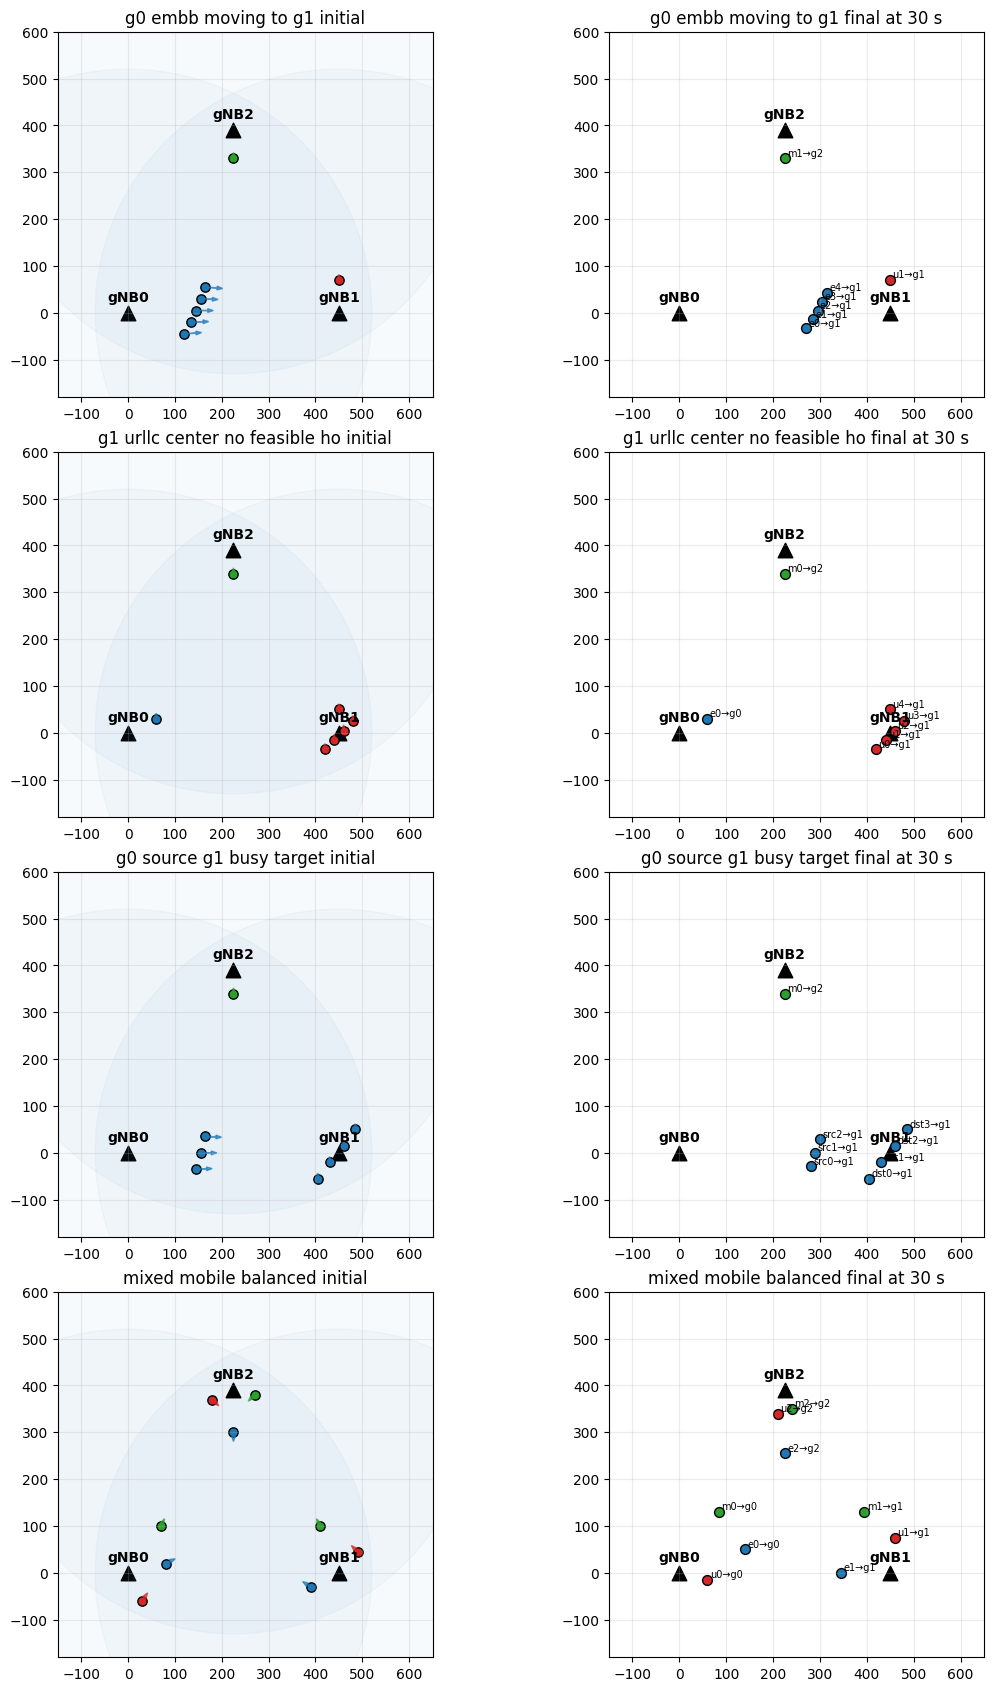

In [14]:
fig, axes = plt.subplots(len(SCENARIOS), 2, figsize=(11, 4.2 * len(SCENARIOS)), constrained_layout=True)
colors = {"eMBB": "tab:blue", "URLLC": "tab:red", "mMTC": "tab:green"}
for row, (scenario, specs) in enumerate(SCENARIOS.items()):
    plot_topology(axes[row, 0], specs, f"{scenario} initial")
    ax = axes[row, 1]
    for cfg in GNB_CONFIGS:
        ax.scatter(cfg["x"], cfg["y"], marker="^", s=110, color="black")
        ax.text(cfg["x"], cfg["y"] + 25, f"gNB{cfg['id']}", ha="center", weight="bold")
    final = final_ue_df[(final_ue_df.scenario == scenario) & (final_ue_df["mode"] == "heuristic")]
    for _, row_ue in final.iterrows():
        ax.scatter(row_ue.x, row_ue.y, color=colors[row_ue["slice"]], edgecolor="black", s=50)
        ax.text(row_ue.x + 5, row_ue.y + 5, f"{row_ue['name']}→g{int(row_ue.serving_gnb)}", fontsize=7)
    ax.set_title(f"{scenario.replace('_', ' ')} final at {SIMULATION_S:.0f} s")
    ax.set_xlim(-150, 650); ax.set_ylim(-180, 600)
    ax.set_aspect("equal"); ax.grid(True, alpha=0.25)
plt.show()

## Final UE service state

In [15]:
display(final_ue_df.sort_values(["scenario", "mode", "ue_id"]).round(3))

,scenario,mode,ue_id,name,slice,x,y,serving_gnb,throughput_bps,queue_bits
0,g0_embb_moving_to_g1,baseline,0,e0,eMBB,270.0,-33.0,1,32380.223,331412664.0
1,g0_embb_moving_to_g1,baseline,1,e1,eMBB,285.0,-14.0,1,42354.812,331838856.0
2,g0_embb_moving_to_g1,baseline,2,e2,eMBB,295.0,5.0,1,39395.552,331963442.0
3,g0_embb_moving_to_g1,baseline,3,e3,eMBB,305.0,24.0,1,37501.945,332009766.0
4,g0_embb_moving_to_g1,baseline,4,e4,eMBB,315.0,43.0,1,45784.284,332022472.0
...,...,...,...,...,...,...,...,...,...,...
57,mixed_mobile_balanced,heuristic,4,u1,URLLC,460.0,75.0,1,254820.407,84507110.0
58,mixed_mobile_balanced,heuristic,5,m1,mMTC,395.0,130.0,1,118441.917,13981346.0
59,mixed_mobile_balanced,heuristic,6,e2,eMBB,225.0,255.0,2,155906.452,179528992.0
60,mixed_mobile_balanced,heuristic,7,u2,URLLC,210.0,340.0,2,278473.902,84083592.0
